In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import joblib
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (roc_auc_score, precision_score, 
                              recall_score, f1_score, 
                              confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler

# Charger KDD Cup 99
df_kdd = pd.read_csv('../data/kdd_cup99.csv')
print(f"Shape : {df_kdd.shape}")
print(f"\nLabels :\n{df_kdd['labels'].value_counts()}")

Shape : (100655, 42)

Labels :
labels
b'normal.'         97278
b'smurf.'           2404
b'neptune.'          899
b'back.'              19
b'ipsweep.'           18
b'satan.'             12
b'portsweep.'          9
b'warezclient.'        7
b'teardrop.'           5
b'pod.'                2
b'nmap.'               1
b'imap.'               1
Name: count, dtype: int64


In [5]:
#  les labels
df_kdd['labels_clean'] = df_kdd['labels'].str.replace("b'", "").str.replace("'", "").str.replace(".", "")
df_kdd['label_binary'] = (df_kdd['labels_clean'] != 'normal').astype(int)

print(f"Normal   : {(df_kdd['label_binary']==0).sum()}")
print(f"Anomalie : {(df_kdd['label_binary']==1).sum()}")
print(f"\nTypes d'attaques : {df_kdd[df_kdd['label_binary']==1]['labels_clean'].unique()}")

# Features numériques
numeric_features = df_kdd.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [f for f in numeric_features if f != 'label_binary']
print(f"\nFeatures numériques KDD : {len(numeric_features)}")

Normal   : 97278
Anomalie : 3377

Types d'attaques : ['smurf' 'neptune' 'back' 'satan' 'warezclient' 'portsweep' 'pod'
 'ipsweep' 'teardrop' 'nmap' 'imap']

Features numériques KDD : 38


In [6]:
# Charger le modèle et config
with open('../models/config.json', 'r') as f:
    config = json.load(f)

# Mapping KDD → CESNET (features similaires)
mapping = {
    'n_flows'               : 'count',
    'n_packets'             : 'src_bytes',
    'n_bytes'               : 'dst_bytes',
    'n_dest_ip'             : 'dst_host_count',
    'n_dest_ports'          : 'dst_host_srv_count',
    'n_dest_asn'            : 'dst_host_diff_srv_rate',
    'tcp_udp_ratio_packets' : 'same_srv_rate',
    'tcp_udp_ratio_bytes'   : 'dst_host_same_srv_rate',
    'dir_ratio_packets'     : 'diff_srv_rate',
    'dir_ratio_bytes'       : 'dst_host_srv_diff_host_rate',
    'avg_duration'          : 'duration',
    'avg_ttl'               : 'dst_host_count'
}

# Créer le DataFrame avec les features mappées
df_mapped = pd.DataFrame()
for cesnet_feat, kdd_feat in mapping.items():
    df_mapped[cesnet_feat] = df_kdd[kdd_feat].values

print(f"Shape mappé : {df_mapped.shape}")
print(f"\nAperçu :")
print(df_mapped.head())

Shape mappé : (100655, 12)

Aperçu :
   n_flows  n_packets  n_bytes  n_dest_ip  n_dest_ports  n_dest_asn  \
0        8        181     5450          9             9         0.0   
1        8        239      486         19            19         0.0   
2        8        235     1337         29            29         0.0   
3        6        219     1337         39            39         0.0   
4        6        217     2032         49            49         0.0   

   tcp_udp_ratio_packets  tcp_udp_ratio_bytes  dir_ratio_packets  \
0                    1.0                  1.0                0.0   
1                    1.0                  1.0                0.0   
2                    1.0                  1.0                0.0   
3                    1.0                  1.0                0.0   
4                    1.0                  1.0                0.0   

   dir_ratio_bytes  avg_duration  avg_ttl  
0              0.0             0        9  
1              0.0             0       

In [7]:
import sys
sys.path.append('../')
from utils.predictor import predict

# Charger config
with open('../models/config.json', 'r') as f:
    config = json.load(f)

threshold = config['threshold']

# Prédiction via predictor.py
result = predict(df_mapped)

predictions = result['labels']
errors = result['errors']
y_true = df_kdd['label_binary'].values

print(f"Threshold             : {threshold:.4f}")
print(f"Prédictions anomalies : {predictions.sum()} ({predictions.mean()*100:.1f}%)")
print(f"Vrais anomalies       : {y_true.sum()} ({y_true.mean()*100:.1f}%)")

Threshold             : 0.1494
Prédictions anomalies : 100655 (100.0%)
Vrais anomalies       : 3377 (3.4%)


In [8]:
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import joblib

# Charger le modèle directement
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(nn.Linear(12, 8), nn.ReLU(), nn.Linear(8, 4), nn.ReLU())
        self.decoder = nn.Sequential(nn.Linear(4, 8), nn.ReLU(), nn.Linear(8, 12))
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = Autoencoder()
model.load_state_dict(torch.load('../models/autoencoder.pth', map_location='cpu'))
model.eval()

# Scaler indépendant entraîné sur KDD
scaler_kdd = StandardScaler()

# Séparer normal et anomalie
df_normal = df_mapped[df_kdd['label_binary'] == 0].copy()
df_anomaly = df_mapped[df_kdd['label_binary'] == 1].copy()

# Log transform
skewed = ['n_flows', 'n_packets', 'n_bytes', 'n_dest_asn', 
          'n_dest_ports', 'n_dest_ip', 'avg_duration']

for col in skewed:
    df_normal[col] = np.log1p(df_normal[col])
    df_anomaly[col] = np.log1p(df_anomaly[col])

# Entraîner le scaler uniquement sur les données normales
X_normal = scaler_kdd.fit_transform(df_normal.values)
X_anomaly = scaler_kdd.transform(df_anomaly.values)

# Combiner
X_all = np.vstack([X_normal, X_anomaly])
y_true = np.hstack([np.zeros(len(X_normal)), np.ones(len(X_anomaly))])

# Prédiction
X_tensor = torch.FloatTensor(X_all)
with torch.no_grad():
    X_pred = model(X_tensor)
    errors = torch.mean((X_tensor - X_pred) ** 2, dim=1).numpy()

# Threshold basé sur les données normales KDD
threshold_kdd = np.percentile(errors[:len(X_normal)], 95)
predictions = (errors > threshold_kdd).astype(int)

print(f"Threshold KDD         : {threshold_kdd:.4f}")
print(f"Prédictions anomalies : {predictions.sum()} ({predictions.mean()*100:.1f}%)")
print(f"Vrais anomalies       : {int(y_true.sum())} ({y_true.mean()*100:.1f}%)")

Threshold KDD         : 2.8484
Prédictions anomalies : 5774 (5.7%)
Vrais anomalies       : 3377 (3.4%)


MÉTRIQUES SUR KDD CUP 99 (Labels Réels)
AUC-ROC   : 0.9473
Precision : 0.1576
Recall    : 0.2695
F1-Score  : 0.1989

Classification Report :
              precision    recall  f1-score   support

      Normal       0.97      0.95      0.96     97278
    Anomalie       0.16      0.27      0.20      3377

    accuracy                           0.93    100655
   macro avg       0.57      0.61      0.58    100655
weighted avg       0.95      0.93      0.94    100655



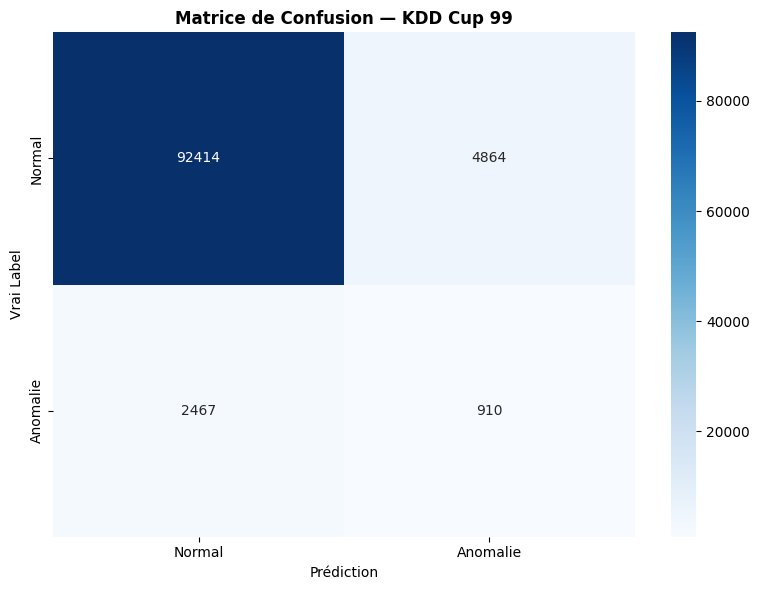

Matrice sauvegardée 


In [9]:
from sklearn.metrics import (roc_auc_score, precision_score, 
                              recall_score, f1_score, 
                              confusion_matrix, classification_report)

# Métriques
auc = roc_auc_score(y_true, errors)
precision = precision_score(y_true, predictions)
recall = recall_score(y_true, predictions)
f1 = f1_score(y_true, predictions)

print("=" * 50)
print("MÉTRIQUES SUR KDD CUP 99 (Labels Réels)")
print("=" * 50)
print(f"AUC-ROC   : {auc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("=" * 50)
print(f"\nClassification Report :")
print(classification_report(y_true, predictions, 
      target_names=['Normal', 'Anomalie']))

# Matrice de confusion
cm = confusion_matrix(y_true, predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Anomalie'],
            yticklabels=['Normal', 'Anomalie'])
plt.title('Matrice de Confusion — KDD Cup 99', fontweight='bold')
plt.ylabel('Vrai Label')
plt.xlabel('Prédiction')
plt.tight_layout()
plt.savefig('../notes/confusion_matrix_kdd.png', dpi=100)
plt.show()
print("Matrice sauvegardée ")